In [17]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import xarray as xr
import os
import matplotlib as mpl
fs=10
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')
from permetrics.regression import RegressionMetric


In [18]:
df = pd.read_excel('nutrients_2018dfo.xlsx',parse_dates=['dtUTC'],index_col=0)
#df = pd.read_csv('PugetSound_2018.csv',parse_dates=['Sample_Date'])
#df = df.drop_duplicates(subset=['Depth', 'folder_day'])
#df = df[df['Sample_Date']>=dt.datetime(2018,2,27)]

In [19]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [20]:
def make_filename(path_run,folder, var='biol_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict"""
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(prefix, fname[0])

In [21]:
mask = xr.open_dataset('/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc')

In [22]:
df['folder_day'] = df['dtUTC'].dt.strftime('%d%b%y').str.lower()
jj = []
ii = []
dd = []
za = []
zb = []
for row in df.itertuples(index=False):
    j,i = finder(row.Lat,row.Lon)
    jj.append(j)
    ii.append(i)
    if row.Depth >= 0 and j>0 and row.Depth != 0.5:
        diff = mask.gdept_0[0,:,j,i].values - row.Depth
        dd.append(diff[diff<0].argmax())
        za.append(mask.gdept_0[0,:,j,i].values[dd[-1]])
        zb.append(mask.gdept_0[0,:,j,i].values[dd[-1]+1])
    elif row.Depth == 0.5 and j>0:
        dd.append(0)
        za.append(0)
        zb.append(1)
    else:
        dd.append('NaN')
        za.append('NaN')
        zb.append('NaN')
        
df['j'] = jj
df['i'] = ii
df['k_above'] = dd
df['z_above'] = za
df['z_bellow'] = zb

In [23]:
def interp_depth(N_shallow, N_deep, z_shallow, z_deep, z_obs):
    return N_shallow + (N_deep - N_shallow) * (z_obs - z_shallow) / (z_deep - z_shallow)

In [24]:
# path = '/home/jvalenti/scratch/run_SHEM/SSBase/'
# N_model = np.full(len(df), np.nan)

# for folder_day, group in df.groupby('folder_day'):
#     try:
#         fn = make_filename(path, folder_day)
#     except FileNotFoundError:
#         continue
#     with xr.open_dataset(fn, engine='h5netcdf') as ds:
#         var = ds['dissolved_oxygen'].isel(time_counter=0)
#         for idx, row in group.iterrows():
#             if row.k_above == 'NaN':
#                 continue
#             ab = var.isel(deptht=slice(row.k_above, row.k_above + 2),y=row.j,x=row.i).values
#             N_model[idx] = interp_depth(ab[0], ab[1],row.z_above, row.z_bellow,row.Depth)
#             print(N_model[idx])
# df['N_model'] = N_model

In [25]:
runs = ['SSBase','SHEM18','diat_pref','exc_hbac','exc_hbac_2','growth_flag','growth_flag_2','mort_hbac','pred_flag','remin','remin2','predmine','mort_hbac_2']

In [26]:
dft = pd.read_excel('DO_model_whole.xlsx',parse_dates=['dtUTC'],index_col=0)

In [27]:
dft.columns

Index(['Year', 'Month', 'Day', 'Hour', 'Lat', 'Lon', 'Pressure', 'Depth',
       'Chlorophyll_Extracted', 'Chlorophyll_Extracted_units', 'N', 'Si',
       'Silicate_units', 'AbsSal', 'ConsT', 'Oxygen_Dissolved',
       'Oxygen_Dissolved_units', 'Z', 'dtUTC', 'folder_day', 'j', 'i',
       'k_above', 'z_above', 'z_bellow', 'SSBase', 'SHEM18', 'diat_pref',
       'exc_hbac', 'exc_hbac_2', 'growth_flag', 'growth_flag_2', 'mort_hbac',
       'pred_flag', 'remin', 'remin2', 'predmine', 'mort_hbac_2'],
      dtype='object')

In [28]:
def calculate_rmse_bias(obs, predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between obs and predicted values.
    """
    # Calculate the squared differences
    differences_squared = (obs - predicted) ** 2
    # Calculate the mean of the squared differences (MSE)
    mean_of_differences_squared = differences_squared.mean()
    # Take the square root (RMSE)
    rmse_val = np.sqrt(mean_of_differences_squared)
    bias = (predicted - obs).mean()
    evaluator = RegressionMetric(np.array(obs), np.array(predicted))
    WI = evaluator.willmott_index()

    return rmse_val, bias,WI

mask_N = (dft.SSBase!= 0) & (~dft.Oxygen_Dissolved.isna()) & (~dft.SSBase.isna())
rmse,bias, WI = calculate_rmse_bias(dft.Oxygen_Dissolved[mask_N], dft.SSBase[mask_N])

print(f"RMSE: {rmse}")
print(f"Bias: {bias}")
print(f"Willmott Index: {WI}")

RMSE: 32.049254125522
Bias: -4.063708933540012
Willmott Index: 0.9148038848662347


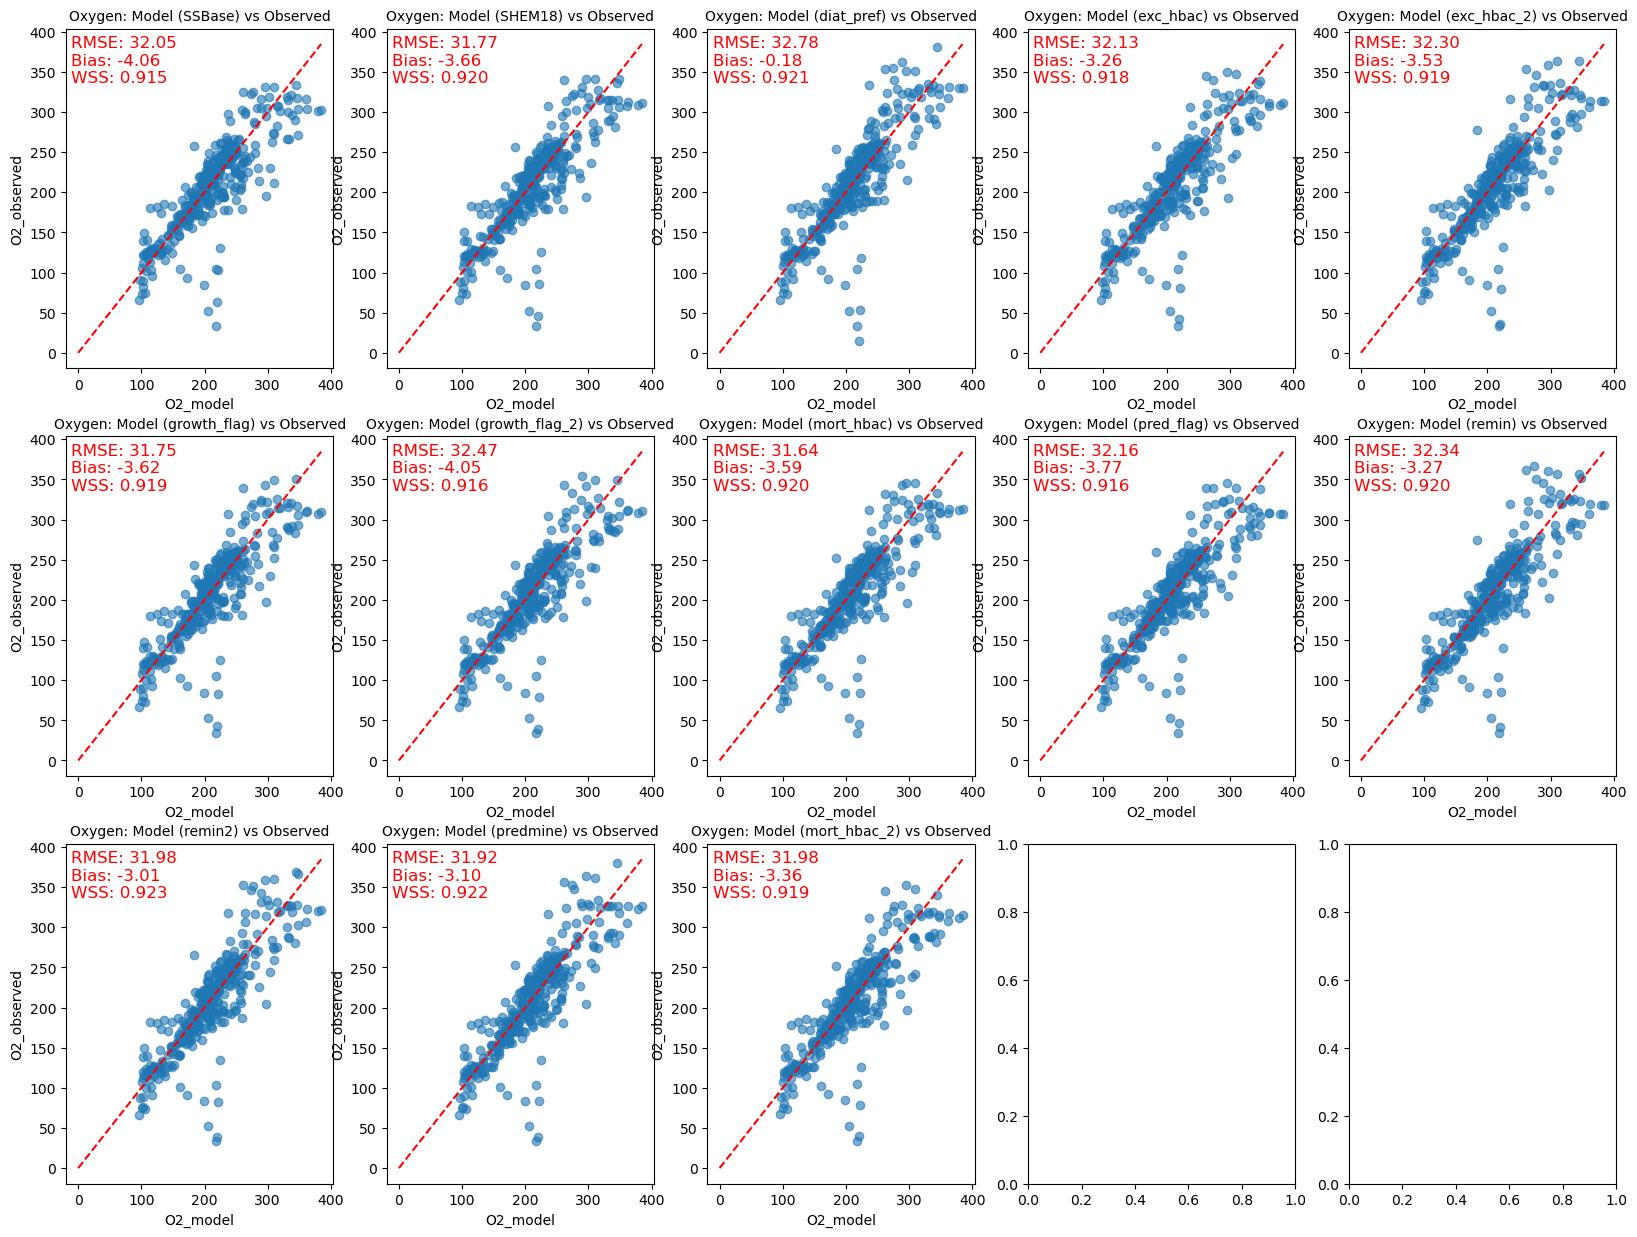

In [29]:
fig, axs = plt.subplots(3, 5, figsize=(20, 15))
axs = axs.flatten()

# Load once
dft = pd.read_excel('DO_model_whole.xlsx', parse_dates=['dtUTC'], index_col=0)
dft = dft[(dft['dtUTC']>=dt.datetime(2018,2,27))&(dft['dtUTC']<=dt.datetime(2018,7,1))]

for i, name in enumerate(runs):
    model = dft[name]
    obs = dft['Oxygen_Dissolved']
    
    mask_N = (model != 0) & (~obs.isna())
    
    rmse, bias, WI = calculate_rmse_bias(obs[mask_N], model[mask_N])
    
    axs[i].scatter(obs[mask_N], model[mask_N],alpha=0.6)
    axs[i].set_xlabel('O2_model')
    axs[i].set_ylabel('O2_observed')
    axs[i].set_title(f'Oxygen: Model ({name}) vs Observed')
    
    max_val = max(model[mask_N].max(), obs[mask_N].max())
    axs[i].plot(
        np.linspace(0, max_val, 100),
        np.linspace(0, max_val, 100),
        'r--'
    )
    
    axs[i].text(0.02, 0.98,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',ha='left',va='top',fontsize=12,transform=axs[i].transAxes,color='red')

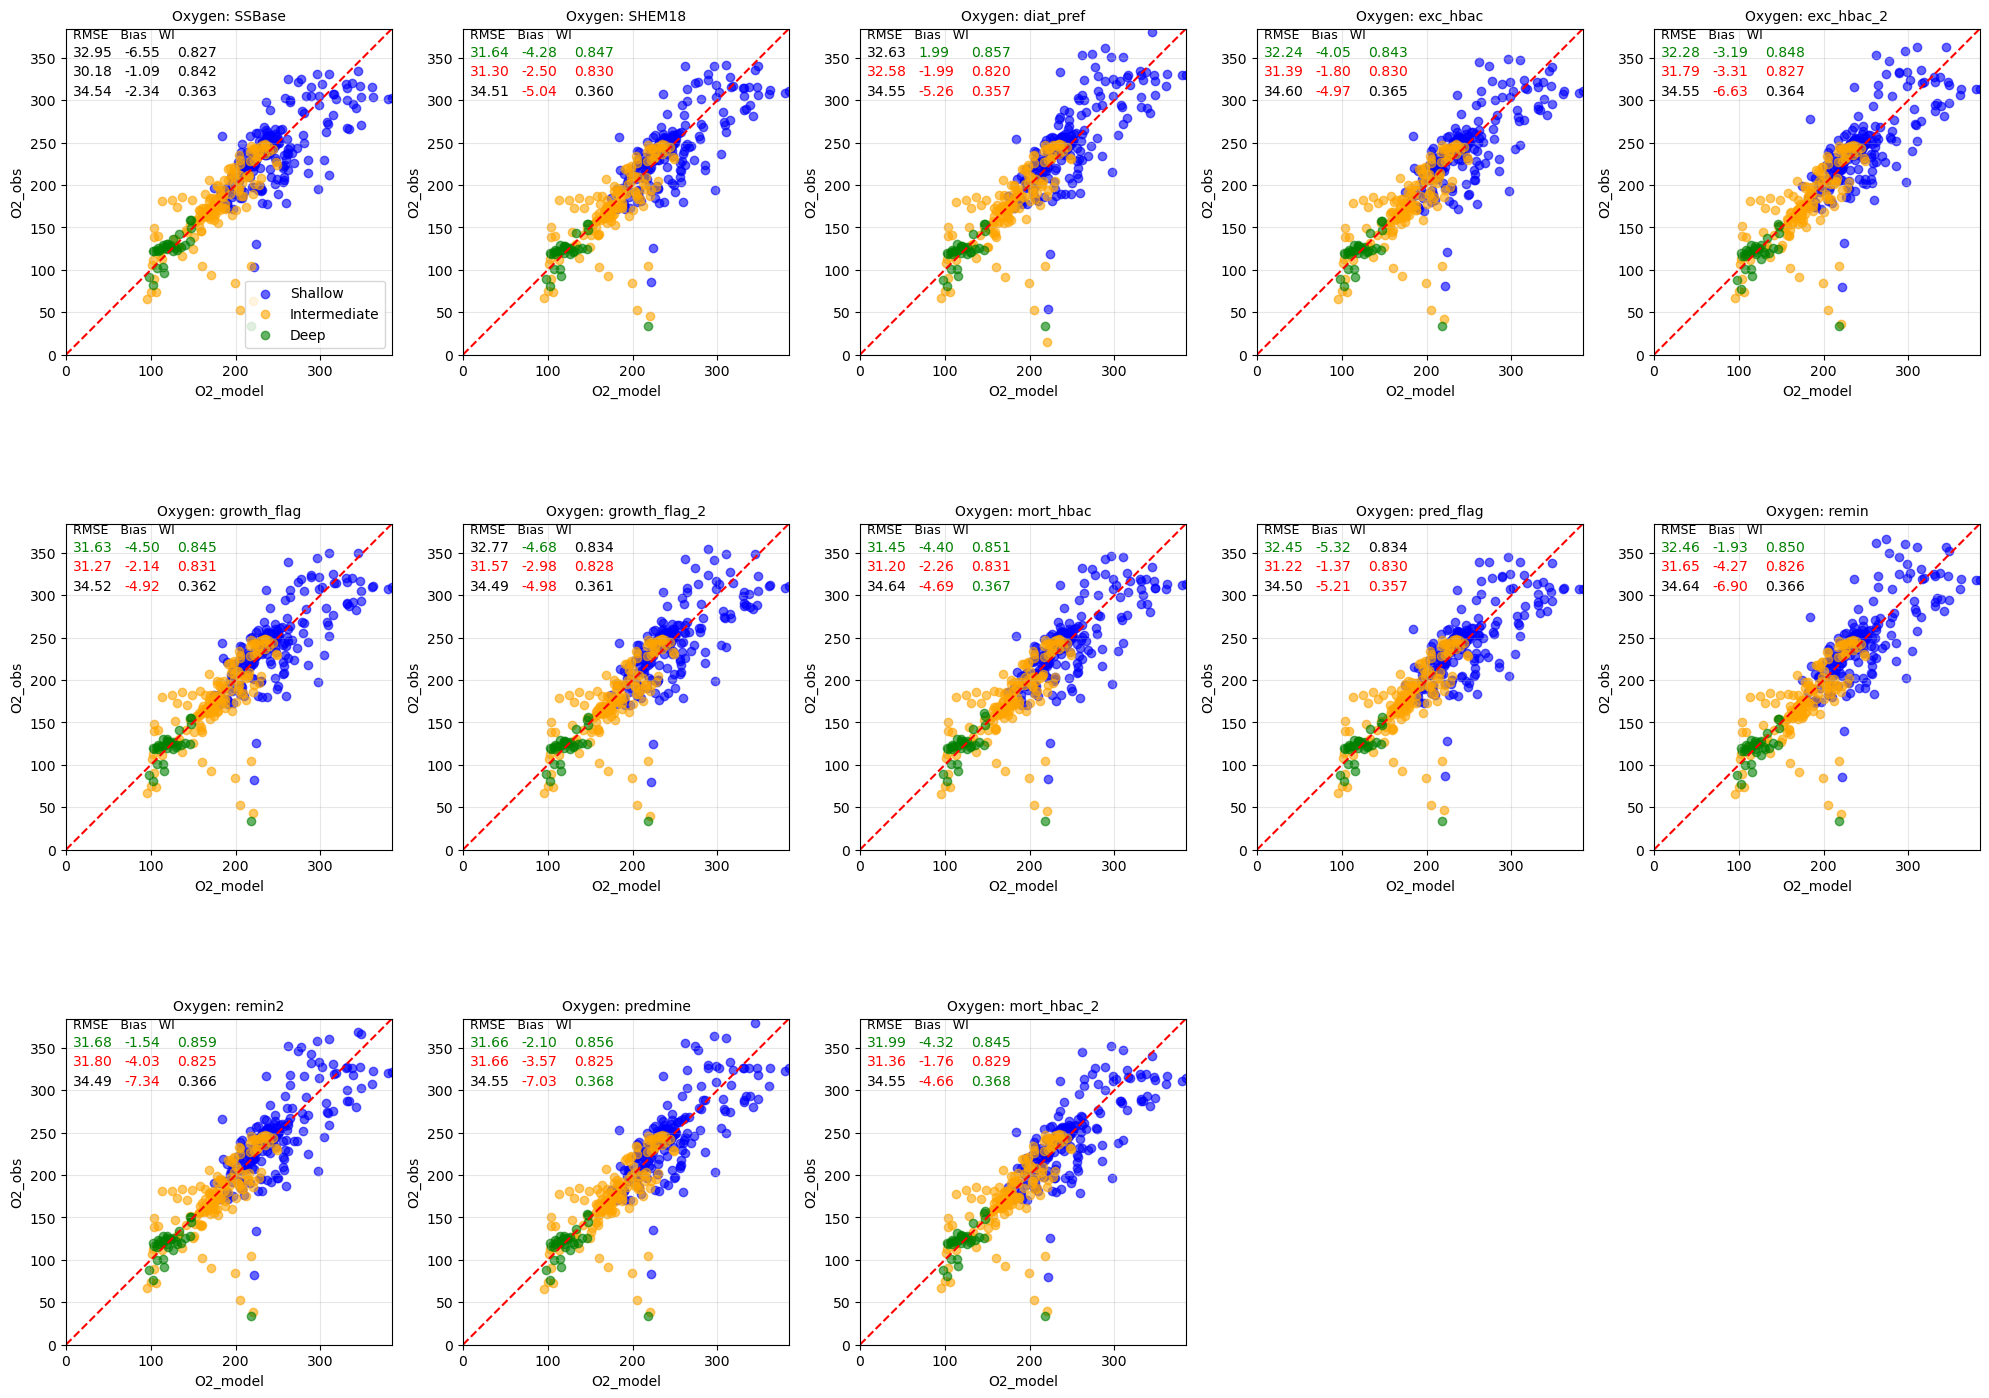

In [31]:
colors = {"Shallow": "blue", "Intermediate": "orange", "Deep": "green"}
depth_limits = [(0, 50), (50, 200), (200, np.inf)]
depth_labels = ["Shallow", "Intermediate", "Deep"]
tol = 0.01

# Load once
dft = pd.read_excel('DO_model_whole.xlsx', parse_dates=['dtUTC'], index_col=0)
dft = dft[(dft['dtUTC']>=dt.datetime(2018,2,27))&(dft['dtUTC']<=dt.datetime(2018,7,1))]

obs, depth = dft['Oxygen_Dissolved'], dft['Depth']

def get_stats(model, mask):
    return calculate_rmse_bias(obs[mask], model[mask]) if mask.any() else (np.nan, np.nan, np.nan)

# --- Baseline ---
base = dft['SSBase']
mask_base = (base != 0) & (~obs.isna()) & (~base.isna())

baseline_stats = [
    get_stats(base, mask_base & depth.between(dmin, dmax, inclusive='left'))
    for dmin, dmax in depth_limits
]

# --- Plot ---
fig, axs = plt.subplots(3, 5, figsize=(20, 15))
axs = axs.flatten()

for i, name in enumerate(runs):
    ax = axs[i]
    model = dft[name]
    mask = (model != 0) & (~obs.isna()) & (~model.isna())

    stats = []

    for (label, (dmin, dmax)), (base_rmse, base_bias, base_WI) in zip(zip(depth_labels, depth_limits), baseline_stats):
        dm = mask & depth.between(dmin, dmax, inclusive='left')
        rmse, bias, WI = get_stats(model, dm)

        if not np.isnan(rmse):
            ax.scatter(obs[dm], model[dm], color=colors[label], alpha=0.6, label=label)

        # Coloring logic
        if name == "SSBase" or np.isnan(rmse):
            stats.append((rmse, bias, WI, "black", "black", "black"))
        else:
            stats.append((rmse, bias, WI,
            "black" if abs(rmse - base_rmse) <= tol*base_rmse else ("green" if rmse < base_rmse else "red"),
            "black" if abs(bias - base_bias) <= tol*base_bias else ("green" if abs(bias) < abs(base_bias) else "red"),
            "black" if abs(WI - base_WI) <= tol*base_WI else ("green" if WI > base_WI else "red")
            ))

    if not mask.any():
        ax.set_title(f'{name} (no data)')
        continue

    max_val = max(obs[mask].max(), model[mask].max())
    ax.plot([0, max_val], [0, max_val], 'r--')
    ax.set(xlim=(0, max_val), ylim=(0, max_val), aspect='equal',
           title=f'Oxygen: {name}', xlabel='O2_model', ylabel='O2_obs')

    if i == 0:
        ax.legend(loc=4)

    # --- Stats text ---
    ax.text(0.02, 0.97, "RMSE   Bias   WI", transform=ax.transAxes, fontsize=9)

    for k, (rmse, bias,wi, c1, c2,c3) in enumerate(stats):
        y = 0.95 - 0.06 * k
        rmse_txt = "—" if np.isnan(rmse) else f"{rmse:.2f}"
        bias_txt = "—" if np.isnan(bias) else f"{bias:.2f}"
        wi_txt = "—" if np.isnan(wi) else f"{wi:.3f}"

        ax.text(0.02, y, rmse_txt, color=c1, transform=ax.transAxes, va='top')
        ax.text(0.18, y, bias_txt, color=c2, transform=ax.transAxes, va='top')
        ax.text(0.34, y, wi_txt, color=c3, transform=ax.transAxes, va='top')

    ax.grid(alpha=0.3)

# Clean unused axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()